# 01 — Exploring the LMC vs Milky Way Training Data

**The problem.** The Large Magellanic Cloud (LMC) is a satellite galaxy of the Milky Way,
about 160,000 light-years away. When Gaia looks toward it, it sees two populations mixed
together on the same patch of sky:

- **LMC stars** — the real members of that distant galaxy.
- **Milky Way foreground stars** — nearby stars in *our own* galaxy that happen to sit
  in the line of sight, in front of the LMC.

Our job is to tell them apart. This first notebook doesn't model anything — it just
**looks at the data** to confirm the physics that makes this separable.

**The data.** `LMC+MW_GOG_trainingset_frac=0.2.csv` is a labelled training set generated by
the **Gaia Object Generator (GOG)** — a physics simulation of what Gaia observes. Because it
is simulated, every row has a trustworthy label in the `Type` column:

- `Type = 1` → LMC star
- `Type = 0` → Milky Way foreground star

**What we expect to see (the discriminating physics):**
1. **Proper motion** (`pmra`, `pmdec`) — the LMC moves across the sky as one coherent blob
   (all its stars share the galaxy's bulk motion). Milky Way foreground stars have their own
   varied motions and scatter widely. → LMC = tight cluster, MW = spread out.
2. **Parallax** — parallax measures distance (bigger = closer). The LMC is so far away its
   parallax is ~0. Nearby MW stars have real, positive parallax. → LMC piles up at 0.


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data")
TRAIN = DATA / "LMC+MW_GOG_trainingset_frac=0.2.csv"
print("training file:", TRAIN, "-", round(TRAIN.stat().st_size/1e6, 1), "MB")

training file: ../data/LMC+MW_GOG_trainingset_frac=0.2.csv - 263.4 MB


## 1. Load the training set

Read all 1.27M rows with Polars. We keep every column — the file is already trimmed to the features that matter.

In [2]:
df = pl.read_csv(TRAIN)
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

shape: 1,269,705 rows x 12 columns


ra,dec,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,parallax,parallax_error,Type
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
91.31831,-70.043099,1.822807,0.113322,0.412407,0.101093,13.394906,13.842181,12.758157,-0.094296,0.203817,1
91.29291,-70.053399,1.848487,0.028495,0.383435,0.02542,13.394204,13.842294,12.76046,0.119042,0.05125,1
91.73641,-70.104399,1.952464,0.196268,0.529635,0.175088,18.949282,19.423347,18.24461,0.00849,0.353,1
91.66971,-70.104799,1.547862,0.210207,0.156403,0.187523,18.950602,19.399714,18.26581,0.002071,0.37807,1
91.59431,-70.036099,1.392517,0.242842,0.377467,0.216636,19.21881,19.686419,18.554773,-0.238032,0.436766,1


## 2. What columns do we have?

Position, proper motion (with errors), three-band photometry, parallax (with error), and the label.

In [3]:
for name, dtype in zip(df.columns, df.dtypes):
    print(f"  {name:22s} {dtype}")

  ra                     Float64
  dec                    Float64
  pmra                   Float64
  pmra_error             Float64
  pmdec                  Float64
  pmdec_error            Float64
  phot_g_mean_mag        Float64
  phot_bp_mean_mag       Float64
  phot_rp_mean_mag       Float64
  parallax               Float64
  parallax_error         Float64
  Type                   Int64


## 3. The label balance

`Type = 1` is LMC, `Type = 0` is Milky Way. We expect the Milky Way foreground to dominate
in raw counts — there are a lot of nearby stars in front of the cloud.

In [4]:
counts = df["Type"].value_counts().sort("Type")
total = df.height
for row in counts.iter_rows(named=True):
    lbl = "LMC" if row["Type"] == 1 else "Milky Way"
    print(f"  Type {row['Type']} ({lbl:9s}): {row['count']:>9,}  ({100*row['count']/total:.1f}%)")

  Type 0 (Milky Way):   992,527  (78.2%)
  Type 1 (LMC      ):   277,178  (21.8%)


## 4. Summary statistics

A quick numeric overview. Note the ranges of proper motion and parallax — the modelling later leans on these.

In [5]:
df.select(["pmra","pmdec","parallax","parallax_error",
           "phot_g_mean_mag","phot_bp_mean_mag","phot_rp_mean_mag"]).describe()

statistic,pmra,pmdec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.269705e6,1.269705e6,1.269705e6,1.269705e6,1.269705e6,1.269705e6,1.269705e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.860668,4.783309,0.612721,0.405197,18.297213,18.857127,17.606234
"""std""",7.604423,9.635026,1.02121,0.408848,1.700226,1.811115,1.666027
"""min""",-495.724063,-1216.825187,-10.418628,0.050255,5.719293,5.799717,4.327068
"""25%""",-1.133848,0.369826,0.095721,0.118724,17.482109,17.964817,16.800358
"""50%""",1.780247,3.256442,0.469624,0.287603,18.763227,19.272096,18.053677
"""75%""",3.657416,7.982599,0.954808,0.549876,19.546543,20.107302,18.8081
"""max""",864.433071,1335.26346,127.906018,6.609758,21.013723,23.913343,22.14539


## 5. Any missing values?

Before trusting the features, check for nulls per column.

In [6]:
nulls = df.null_count()
any_null = False
for name in df.columns:
    n = nulls[name][0]
    if n > 0:
        print(f"  {name}: {n:,} nulls")
        any_null = True
if not any_null:
    print("  No missing values in any column - clean dataset.")

  No missing values in any column - clean dataset.


## 6. The key plot: proper motion

This is the single most important view. Each point is a star, plotted by its proper motion
in RA (`pmra`) vs Dec (`pmdec`). We colour LMC (orange) over Milky Way (grey).

**If the physics holds, the orange LMC points should form a tight, distinct clump** — the
galaxy's coherent bulk motion — while the grey Milky Way points scatter broadly around it.

(We plot a random 60,000-point sample so the figure stays readable; the full set is 1.27M.)

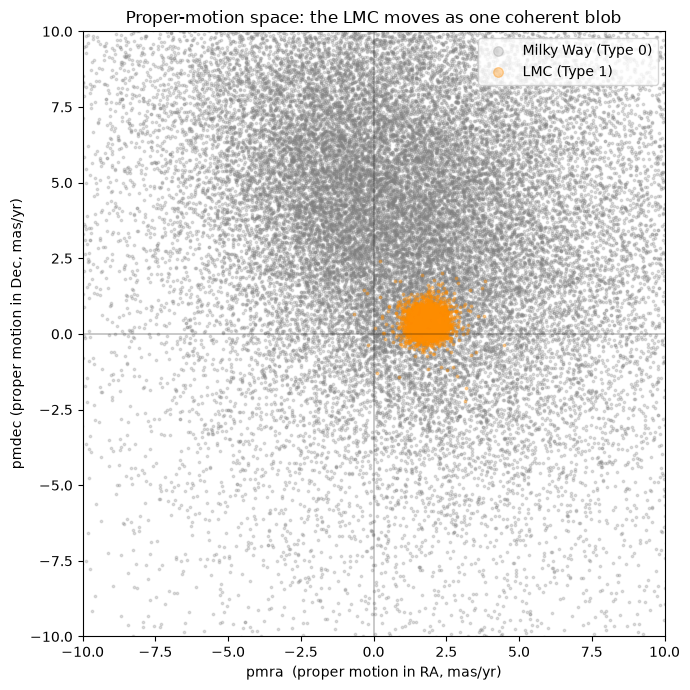

In [7]:
rng = np.random.default_rng(0)
idx = rng.choice(df.height, size=min(60_000, df.height), replace=False)
samp = df[idx]

mw  = samp.filter(pl.col("Type") == 0)
lmc = samp.filter(pl.col("Type") == 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(mw["pmra"],  mw["pmdec"],  s=3, alpha=0.25, c="grey",   label="Milky Way (Type 0)")
ax.scatter(lmc["pmra"], lmc["pmdec"], s=3, alpha=0.35, c="darkorange", label="LMC (Type 1)")
ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
ax.set_xlabel("pmra  (proper motion in RA, mas/yr)")
ax.set_ylabel("pmdec (proper motion in Dec, mas/yr)")
ax.set_title("Proper-motion space: the LMC moves as one coherent blob")
ax.legend(markerscale=4, loc="upper right")
ax.axhline(0, color="k", lw=0.3); ax.axvline(0, color="k", lw=0.3)
plt.tight_layout(); plt.show()

## 7. Parallax: the LMC is far, so its parallax ~ 0

Parallax is the tiny apparent shift of a star caused by Earth's orbit — bigger for closer
stars. The LMC is ~160,000 ly away, so its true parallax is essentially zero (measurements
scatter around 0 due to noise). Nearby Milky Way stars have real positive parallax.

We expect the **LMC distribution to be a sharp spike at 0**, and the **Milky Way to have a
broader tail toward positive parallax**.

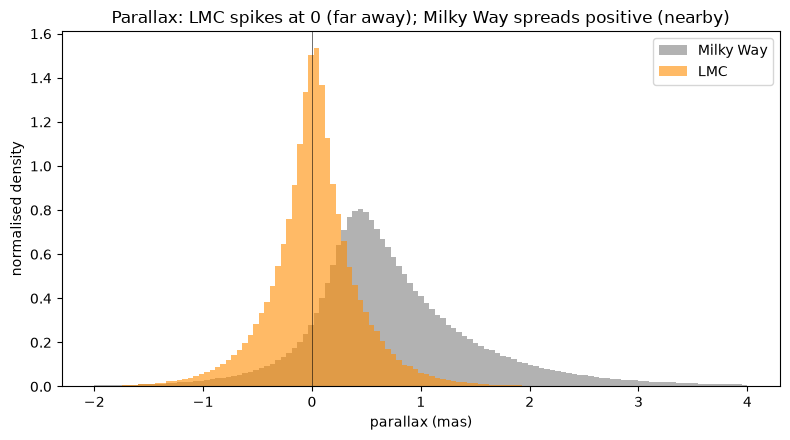

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(-2, 4, 120)
ax.hist(df.filter(pl.col("Type")==0)["parallax"], bins=bins, alpha=0.6,
        color="grey", label="Milky Way", density=True)
ax.hist(df.filter(pl.col("Type")==1)["parallax"], bins=bins, alpha=0.6,
        color="darkorange", label="LMC", density=True)
ax.set_xlabel("parallax (mas)"); ax.set_ylabel("normalised density")
ax.set_title("Parallax: LMC spikes at 0 (far away); Milky Way spreads positive (nearby)")
ax.axvline(0, color="k", lw=0.4); ax.legend()
plt.tight_layout(); plt.show()

## 8. Colour–magnitude view

Using the three Gaia bands we form a colour `bp_rp = phot_bp_mean_mag - phot_rp_mean_mag`
(blue minus red — a proxy for temperature) and plot it against G-band brightness.

**Reminder:** astronomical magnitudes run *backwards* — smaller = brighter — so we invert
the y-axis. The two populations trace different stellar sequences, giving the model extra
signal beyond motion and distance.

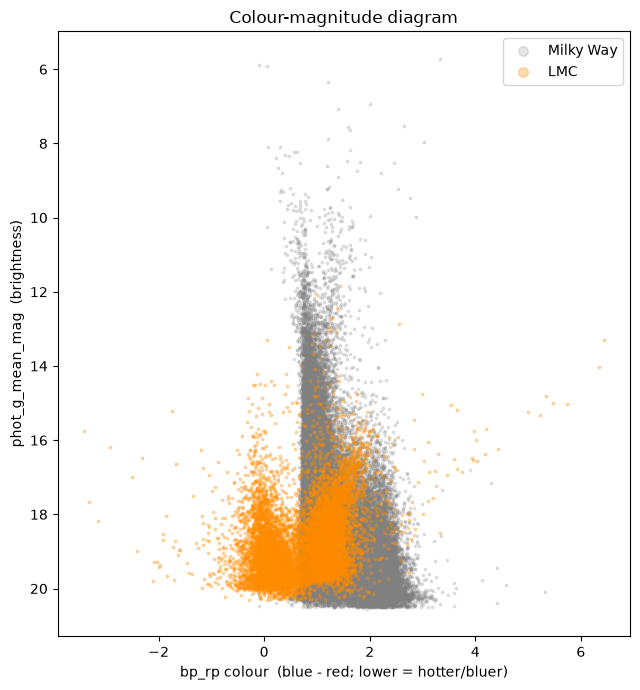

In [9]:
d = df.with_columns((pl.col("phot_bp_mean_mag") - pl.col("phot_rp_mean_mag")).alias("bp_rp"))
ds = d[idx]
mw2  = ds.filter(pl.col("Type")==0)
lmc2 = ds.filter(pl.col("Type")==1)

fig, ax = plt.subplots(figsize=(6.5, 7))
ax.scatter(mw2["bp_rp"],  mw2["phot_g_mean_mag"],  s=3, alpha=0.2,  c="grey",       label="Milky Way")
ax.scatter(lmc2["bp_rp"], lmc2["phot_g_mean_mag"], s=3, alpha=0.3,  c="darkorange", label="LMC")
ax.set_xlabel("bp_rp colour  (blue - red; lower = hotter/bluer)")
ax.set_ylabel("phot_g_mean_mag  (brightness)")
ax.set_title("Colour-magnitude diagram")
ax.invert_yaxis()  # brighter at top
ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

## 9. Where on the sky?

Finally, plot RA vs Dec. The LMC should appear as a **concentrated clump** (it's a compact
galaxy), while the Milky Way foreground is spread more evenly across the field.

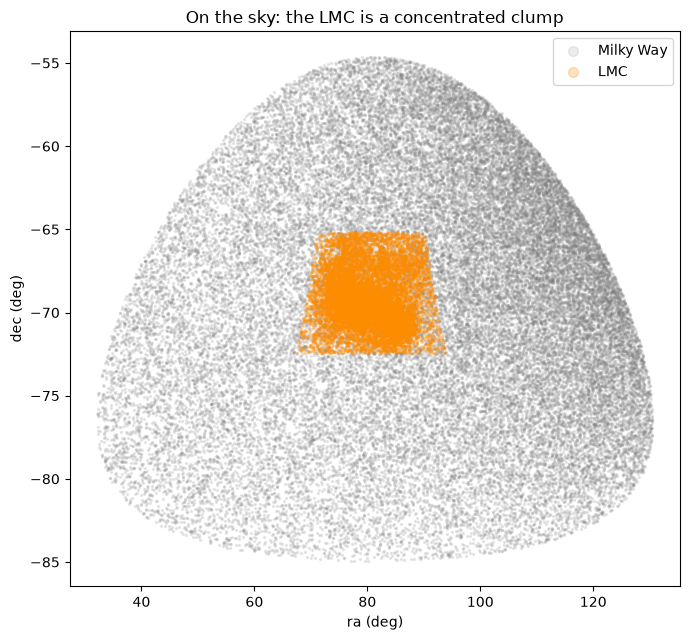

In [10]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(mw["ra"],  mw["dec"],  s=2, alpha=0.15, c="grey",       label="Milky Way")
ax.scatter(lmc["ra"], lmc["dec"], s=2, alpha=0.25, c="darkorange", label="LMC")
ax.set_xlabel("ra (deg)"); ax.set_ylabel("dec (deg)")
ax.set_title("On the sky: the LMC is a concentrated clump")
ax.legend(markerscale=5)
plt.tight_layout(); plt.show()

## What we learned

- The dataset is **clean** (checked for nulls) and **large** (1.27M labelled rows).
- The classes are **imbalanced** (~78% Milky Way / ~22% LMC) — we'll account for that when training.
- The physics is **visible and strong**:
  - LMC stars form a **tight blob in proper-motion space**; the Milky Way scatters. This is the
    single strongest signal.
  - LMC **parallax spikes at 0** (it's far); the Milky Way spreads to positive values.
  - The two populations trace **different colour–magnitude sequences** and the LMC is
    **concentrated on the sky**.

This tells us a classifier built on proper motion + parallax + photometry should separate
the two populations well. **Next (notebook 02): train that baseline classifier and measure it.**
